In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import majordome as mj
import pyvista as pv
from IPython.display import Markdown, display

import project as ma

supply, table_fuel1, table_oxid1 = ma.load_setup_shared(air_temp=25)
supply, table_fuel2, table_oxid2 = ma.load_setup_shared(air_temp=300)

mesh1 = ma.load_case("solution.1", True, show_plot=False, verbose=False)
mesh2 = ma.load_case("solution.2", True, show_plot=False, verbose=False)

## Process conditions

In the present study we compare the combustion behavior of a fixed flow rate of methane (125 Nm³/h) under different combustion air temperatures (25 °C and 300 °C). Air flow rate is evaluated to match the global stoichiometric combustion of the supplied methane. All thermodynamics calculations (such as fuel heating value) and simulations (kinetics used in CFD) carried with [BFER_methane](https://chemistry.cerfacs.fr/en/chemical-database/mechanisms-list/bfer-methane-air-mechanism/) mechanism from CERFACS. @tbl-summary-combustion summarizes process conditions and quantities of interest for verification.

<!--  The full paper is provided [here](https://chemistry.cerfacs.fr/wp-content/uploads/sites/76/2018/08/CF_Preccinsta.pdf). -->

In [2]:
#| echo: false
#| tbl-cap: Summary of energy input conditions.
#| label: tbl-summary-combustion
_ = supply.report(notebook=True)

| Property                  | Unit   |     Value |
|---------------------------|--------|-----------|
| Required power            | kW     | 1243.27   |
| Lower heating value       | MJ/kg  |   50.0254 |
| Fuel mass flow rate       | kg/h   |   89.4699 |
| Oxidizer mass flow rate   | kg/h   | 1532.35   |
| Total mass flow rate      | kg/h   | 1621.82   |
| Fuel volume flow rate     | Nm³/h  |  125      |
| Oxidizer volume flow rate | Nm³/h  | 1190.48   |
| Total volume flow rate    | Nm³/h  | 1315.48   |
| Water production          | kg/h   |  200.935  |
| Carbon dioxide production | kg/h   |  245.433  |
| Total emissions           | kg/h   |  446.368  |

@tbl-system-dimensions provides the main dimensions of the systems. Together with the values provided in @tbl-summary-combustion they are used to compute the boundary conditions that follow. These dimensions are used to simplify a more complex burner composed of 4 fuel injectors (of 27 mm each) while keeping surrounding air velocity constant by enforcing the ratio of cross-sections constant.

In [3]:
#| echo: false
#| tbl-cap: System dimensions
#| label: tbl-system-dimensions
display(Markdown(ma.tabulate_dimensions()))

| Quantity                      | Unit   |   Value |
|-------------------------------|--------|---------|
| Fuel inlet diameter           | mm     |      27 |
| Oxidizer inlet inner diameter | mm     |      32 |
| Oxidizer inlet outer diameter | mm     |     199 |
| Domain diameter               | mm     |     866 |
| Domain length                 | m      |       4 |

@tbl-conditions-fuel provides the fuel operating conditions in units compatible with the simulation setup. These values are used for both cases considered in this study. Estimations of turbulent conditions assumed a turbulent intensity of 5%.

In [4]:
#| echo: false
#| tbl-cap: Conditions evaluated for fuel.
#| label: tbl-conditions-fuel
display(Markdown(table_fuel1))

| Quantity                   | Unit   |     Value |
|----------------------------|--------|-----------|
| Temperature                | K      |  298.15   |
| Mean velocity              | m/s    |   66.1948 |
| Characteristic length      | mm     |    1.89   |
| Turbulent kinetic energy   | m²/s²  |   16.4316 |
| Turbulent dissipation rate | m²/s³  | 5790.79   |

@tbl-conditions-oxidizer-1 provides room temperature air conditions computed under similar assumptions.

In [5]:
#| echo: false
#| tbl-cap: Conditions evaluated for room temperature oxidizer.
#| label: tbl-conditions-oxidizer-1
display(Markdown(table_oxid1))

| Quantity                   | Unit   |     Value |
|----------------------------|--------|-----------|
| Temperature                | K      | 298.15    |
| Mean velocity              | m/s    |  16.5335  |
| Characteristic length      | mm     |  11.6707  |
| Turbulent kinetic energy   | m²/s²  |   1.02508 |
| Turbulent dissipation rate | m²/s³  |  14.6125  |

Similarly, @tbl-conditions-oxidizer-2 provides the conditions for pre-heated air.

In [6]:
#| echo: false
#| tbl-cap: Conditions evaluated for pre-heated oxidizer.
#| label: tbl-conditions-oxidizer-2
display(Markdown(table_oxid2))

| Quantity                   | Unit   |     Value |
|----------------------------|--------|-----------|
| Temperature                | K      | 573.15    |
| Mean velocity              | m/s    |  31.7832  |
| Characteristic length      | mm     |  11.6707  |
| Turbulent kinetic energy   | m²/s²  |   3.78814 |
| Turbulent dissipation rate | m²/s³  | 103.806   |

Walls are modeled through a global heat transfer coefficient representing a refractory of 280 mm (thermal conductivity 1.8 W/(m.K)) sourrounded by steady air at room temperature (heat transfer coefficient 10 W/(m².K)).

{{< pagebreak >}}

## Results

In this section we present a selection of field views for the main variables of interest. All figures are structured the same way, with the reference room temperature results on top, and pre-heated air on the bottom. Care was taken to display both fields with the same color scale.

::: {.callout-warning}
This is a work in progress, discussion of results is yet to be done.
:::

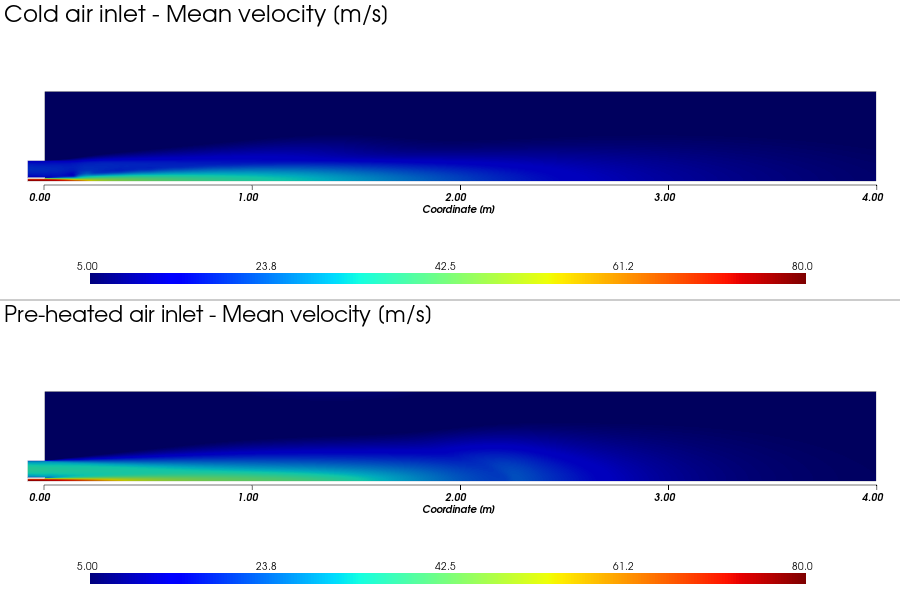

In [7]:
#| echo: false
#| fig-align: center
#| fig-cap: Velocity magnitude fields [m/s].
#| label: fig-field-velocity
ma.plot_comparison(
    mesh1, mesh2, scalar="U", cmap="jet", clim=[5.0, 80.0]
)

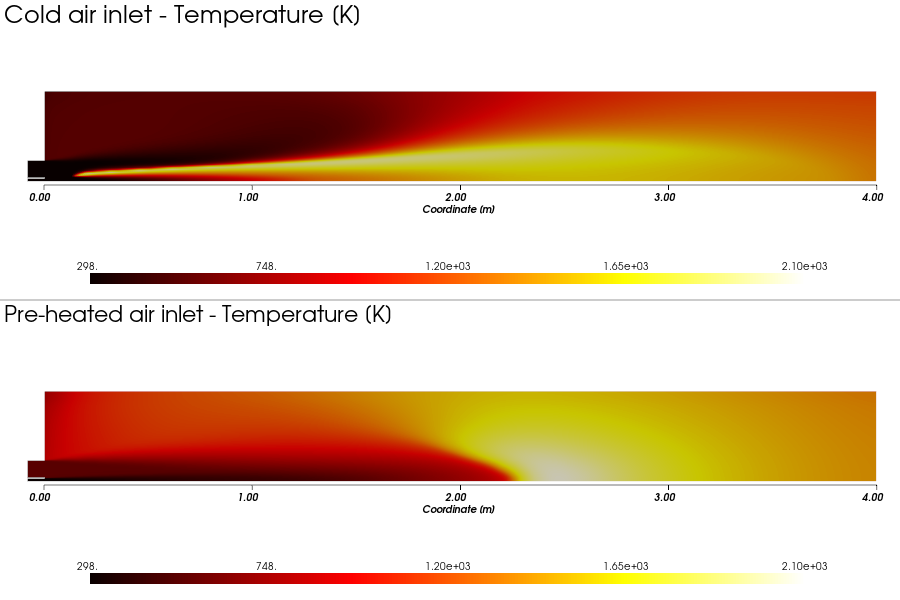

In [8]:
#| echo: false
#| fig-align: center
#| fig-cap: Temperature fields [K].
#| label: fig-field-temperature
ma.plot_comparison(
    mesh1, mesh2, scalar="T", cmap="hot", clim=[298.0, 2100.0]
)

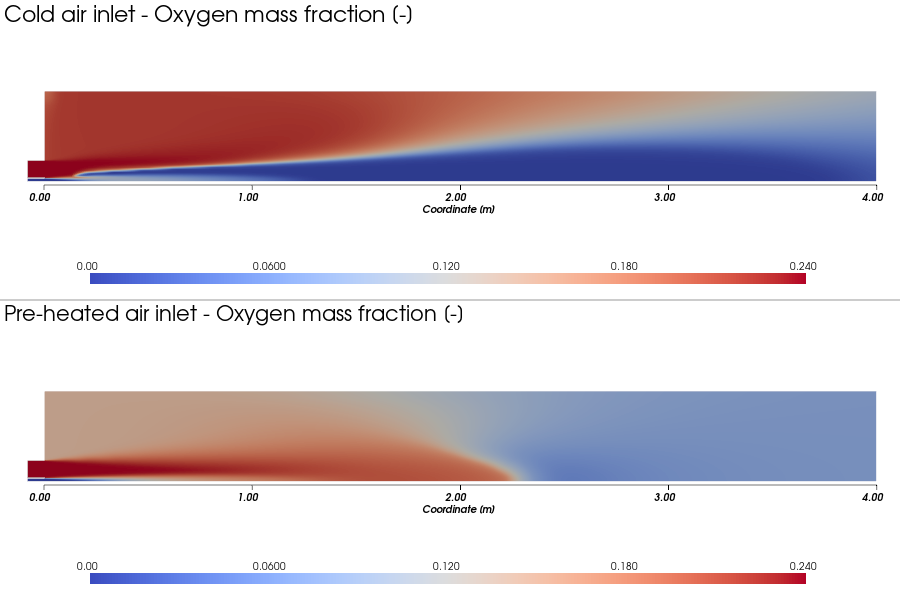

In [9]:
#| echo: false
#| fig-align: center
#| fig-cap: Oxygen mass fraction fields [-].
#| label: fig-field-oxygen
ma.plot_comparison(
    mesh1, mesh2, scalar="O2", cmap="coolwarm", clim=[0.0, 0.24]
)

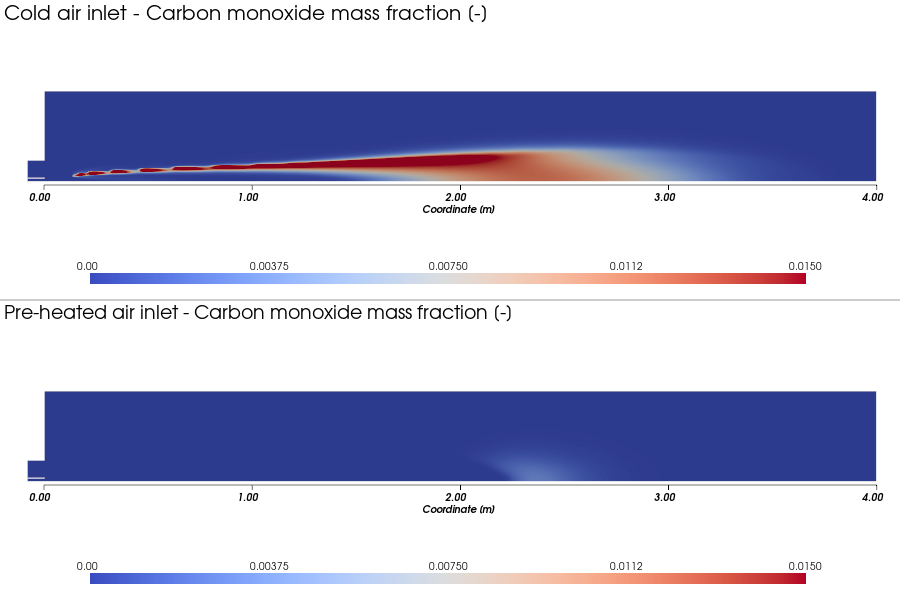

In [10]:
#| echo: false
#| fig-align: center
#| fig-cap: Carbon monoxide mass fraction fields [-].
#| label: fig-field-carbon-monoxide
ma.plot_comparison(
    mesh1, mesh2, scalar="CO", cmap="coolwarm", clim=[0.0, 0.015]
)

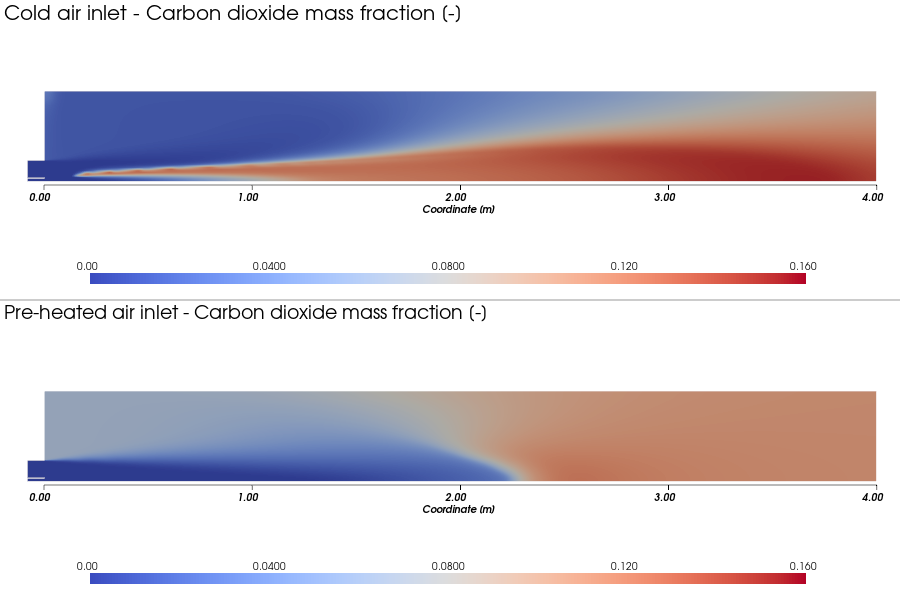

In [11]:
#| echo: false
#| fig-align: center
#| fig-cap: Carbon dioxide mass fraction fields [-].
#| label: fig-field-carbon-dioxide
ma.plot_comparison(
    mesh1, mesh2, scalar="CO2", cmap="coolwarm", clim=[0.0, 0.16]
)

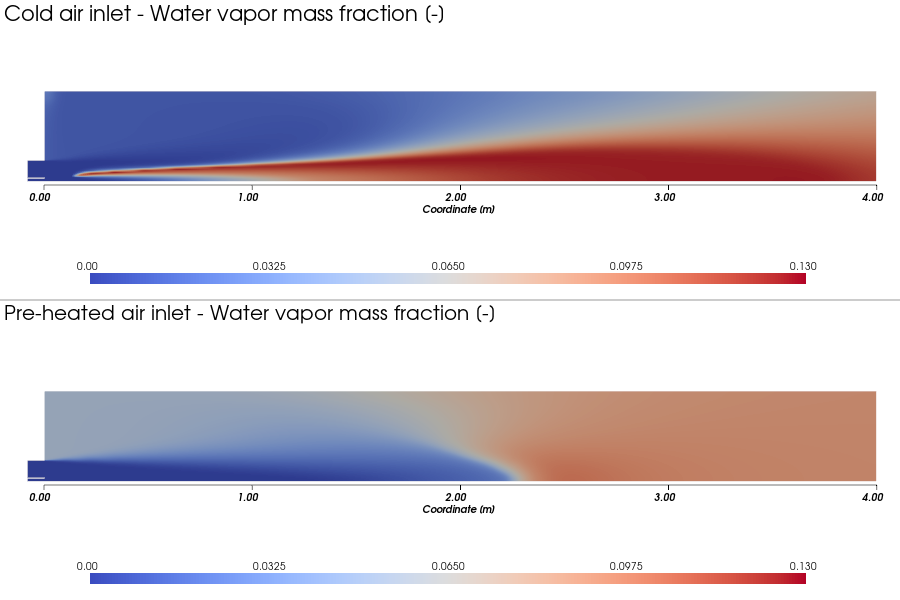

In [12]:
#| echo: false
#| fig-align: center
#| fig-cap: Water vapor mass fraction fields [-].
#| label: fig-field-water-vapor
ma.plot_comparison(
    mesh1, mesh2, scalar="H2O", cmap="coolwarm", clim=[0.0, 0.13]
)

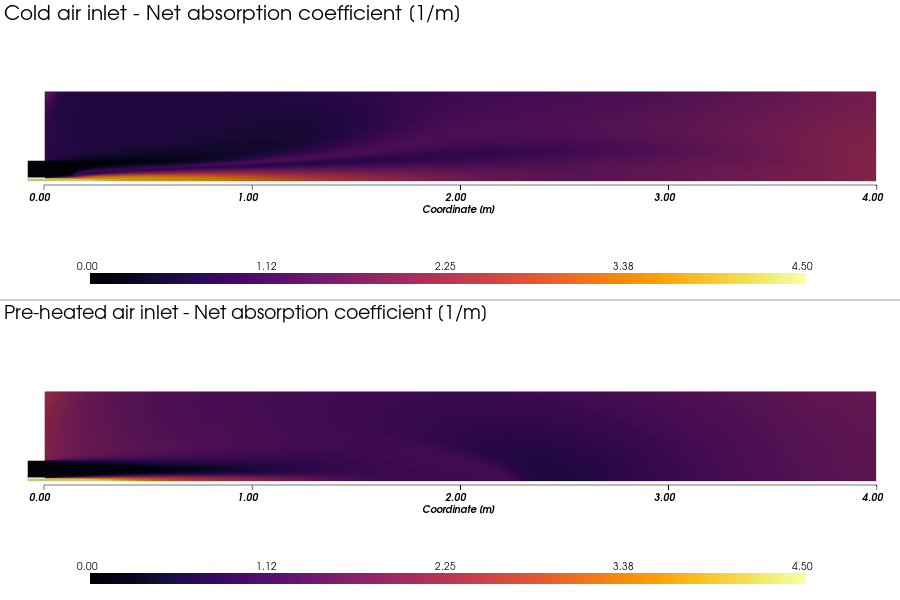

In [13]:
#| echo: false
#| fig-align: center
#| fig-cap: Net absorption coefficient fields [1/m].
#| label: fig-field-absorption
ma.plot_comparison(
    mesh1, mesh2, scalar="a", cmap="inferno", clim=[0.0, 4.5]
)

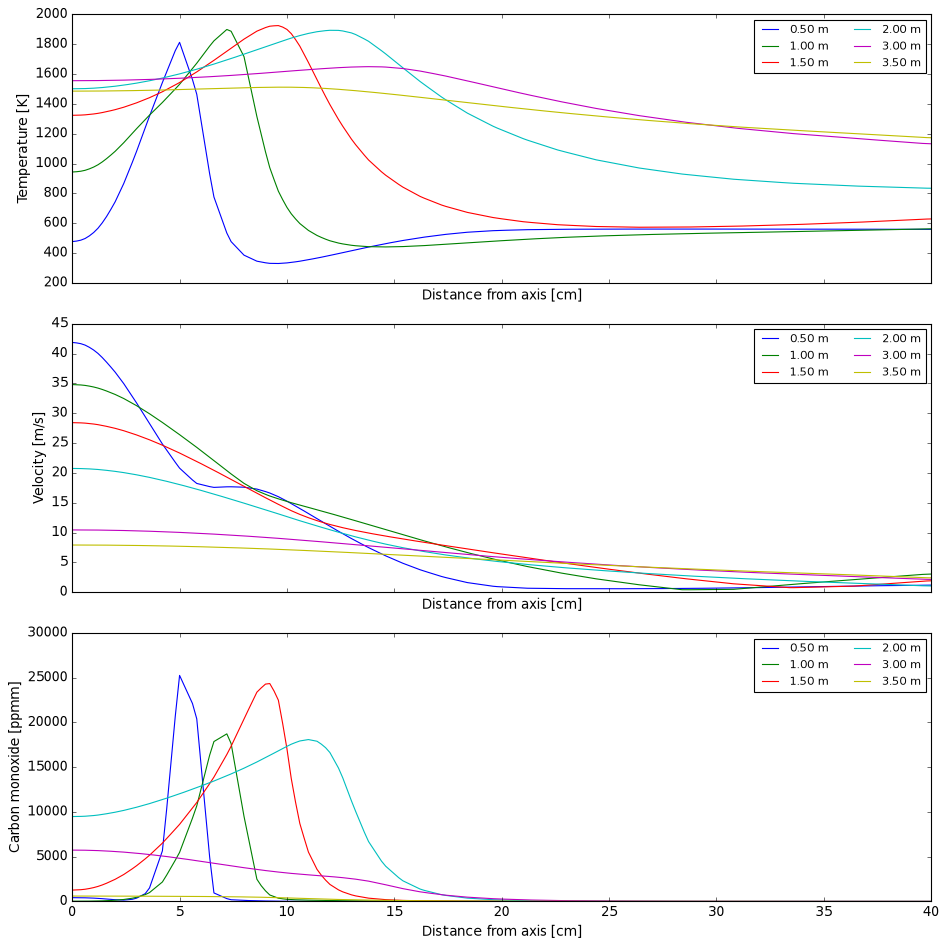

In [14]:
#| echo: false
#| fig-align: center
#| fig-cap: Extraction over selected axial coordinates (room temperature air).
#| label: fig-slices-1
_ = ma.plot_fields(mesh1)

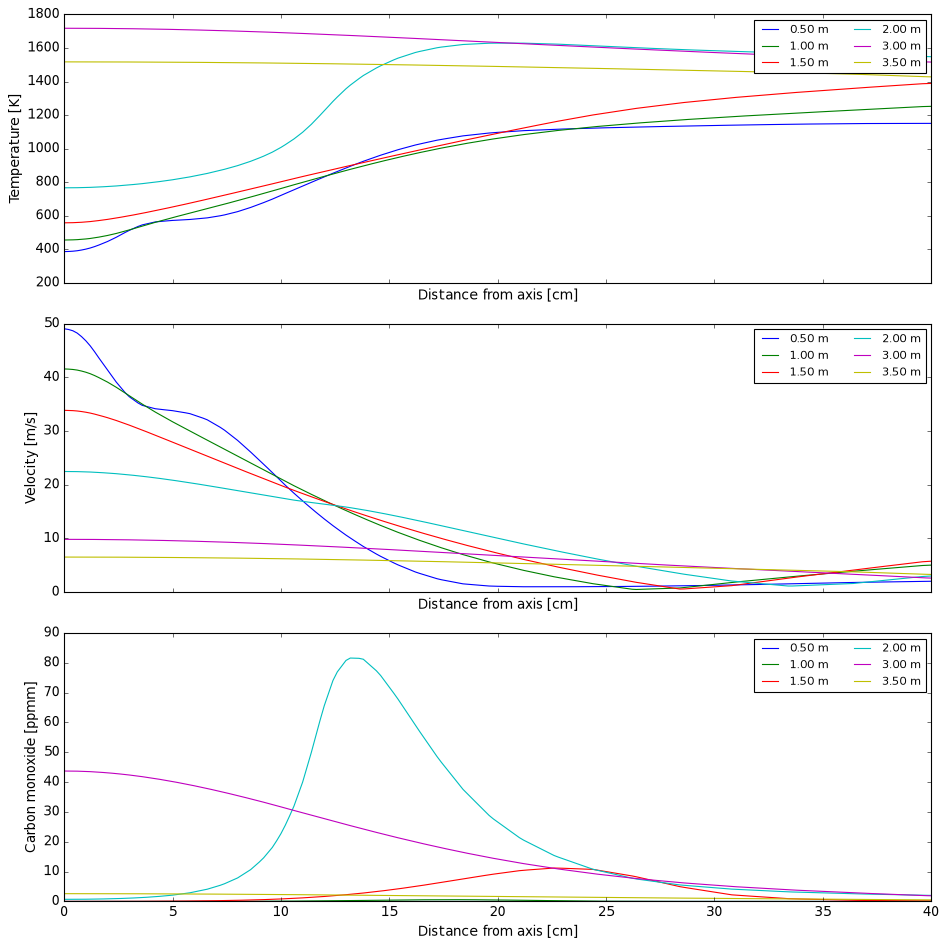

In [15]:
#| echo: false
#| fig-align: center
#| fig-cap: Extraction over selected axial coordinates (pre-heated air).
#| label: fig-slices-2
_ = ma.plot_fields(mesh2)